In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Cargar la base procesada
df = pd.read_csv('../data/processed/datos_procesados.csv', index_col=0, parse_dates=True)
print("📊 Datos cargados para exploración:")
df.head()

# Selección de variables en niveles y en logaritmos
vars_niveles = ['PIB', 'PET', 'EMBI', 'CRED']
vars_logs = ['L_PIB', 'L_PET', 'L_EMBI', 'L_CRED']

print("--- ESTADÍSTICAS DESCRIPTIVAS EN NIVELES ---")
display(df[vars_niveles].describe().T[['mean', 'std', 'min', '50%', 'max']])

print("\n--- ESTADÍSTICAS DESCRIPTIVAS EN LOGARITMOS ---")
display(df[vars_logs].describe().T[['mean', 'std', 'min', '50%', 'max']])

📊 Datos cargados para exploración:
--- ESTADÍSTICAS DESCRIPTIVAS EN NIVELES ---


,mean,std,min,50%,max
PIB,18669.975556,2184.748899,15288.45,18316.64,22592.15
PET,70.062063,18.485996,31.90,68.83,104.73
EMBI,1166.825397,619.282299,595.00,1052.00,3692.00
CRED,14738.585238,3847.341120,7960.85,14625.61,21133.15



--- ESTADÍSTICAS DESCRIPTIVAS EN LOGARITMOS ---


,mean,std,min,50%,max
L_PIB,9.827957,0.116757,9.634853,9.815565,10.025358
L_PET,4.212816,0.278077,3.462606,4.231640,4.651386
L_EMBI,6.978010,0.374934,6.388561,6.958448,8.213924
L_CRED,9.562353,0.275284,8.982291,9.590529,9.958598


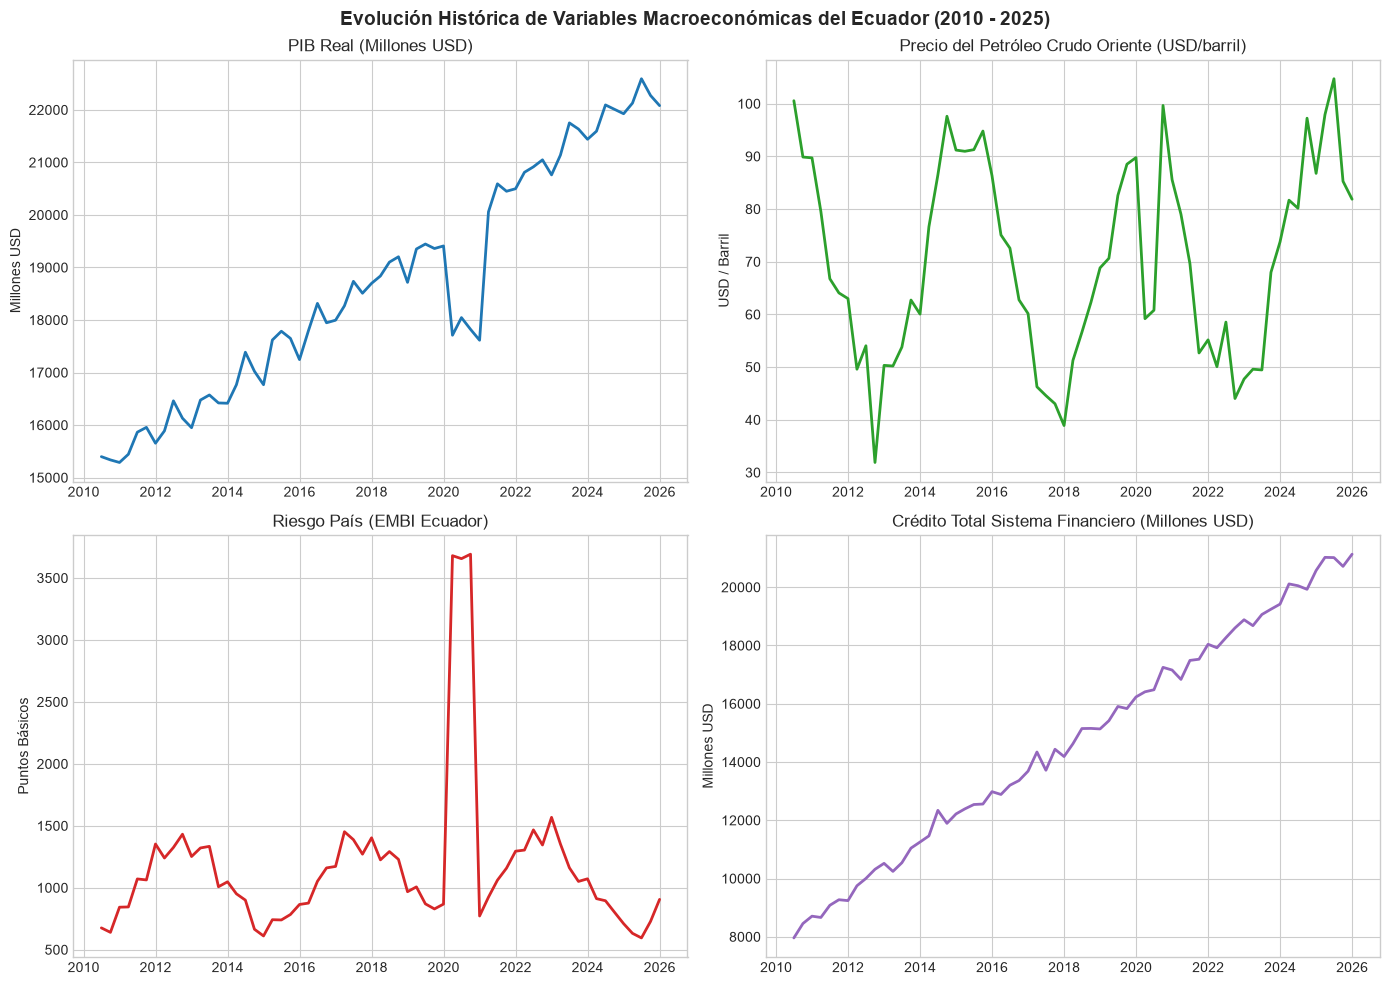

✅ Gráfico guardado en outputs/figures/01_series_niveles.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Evolución Histórica de Variables Macroeconómicas del Ecuador (2010 - 2025)', fontsize=14, fontweight='bold')

# 1. PIB Real
axes[0, 0].plot(df.index, df['PIB'], color='#1f77b4', linewidth=2)
axes[0, 0].set_title('PIB Real (Millones USD)')
axes[0, 0].set_ylabel('Millones USD')

# 2. Precio Petróleo
axes[0, 1].plot(df.index, df['PET'], color='#2ca02c', linewidth=2)
axes[0, 1].set_title('Precio del Petróleo Crudo Oriente (USD/barril)')
axes[0, 1].set_ylabel('USD / Barril')

# 3. Riesgo País
axes[1, 0].plot(df.index, df['EMBI'], color='#d62728', linewidth=2)
axes[1, 0].set_title('Riesgo País (EMBI Ecuador)')
axes[1, 0].set_ylabel('Puntos Básicos')

# 4. Crédito Total
axes[1, 1].plot(df.index, df['CRED'], color='#9467bd', linewidth=2)
axes[1, 1].set_title('Crédito Total Sistema Financiero (Millones USD)')
axes[1, 1].set_ylabel('Millones USD')

plt.tight_layout()
plt.savefig('../outputs/figures/01_series_niveles.png', dpi=300)
plt.show()
print("✅ Gráfico guardado en outputs/figures/01_series_niveles.png")


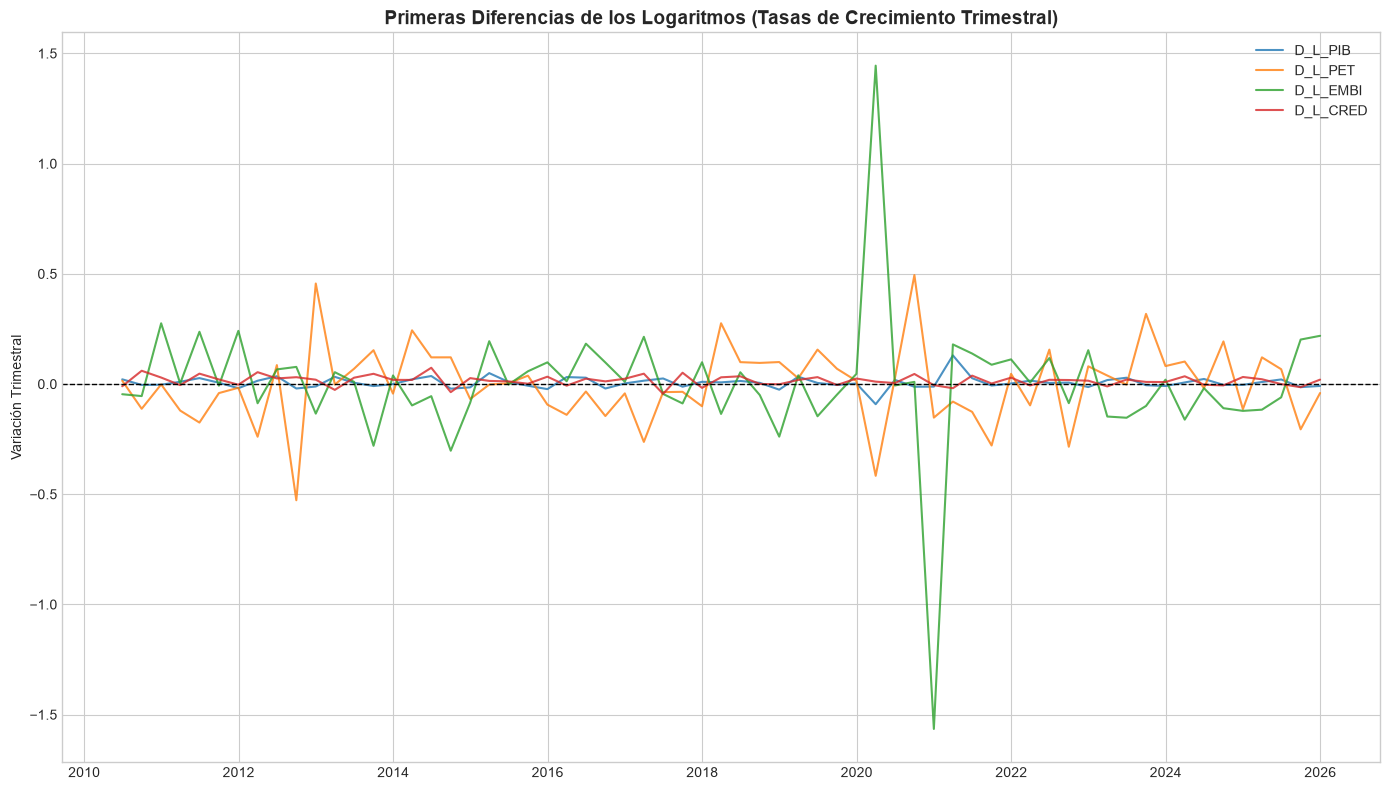

✅ Gráfico guardado en outputs/figures/02_series_diferencias.png


In [5]:
vars_diff = ['D_L_PIB', 'D_L_PET', 'D_L_EMBI', 'D_L_CRED']

plt.figure(figsize=(14, 8))
for col in vars_diff:
    plt.plot(df.index, df[col], label=col, alpha=0.8, linewidth=1.5)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Primeras Diferencias de los Logaritmos (Tasas de Crecimiento Trimestral)', fontsize=14, fontweight='bold')
plt.ylabel('Variación Trimestral')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/figures/02_series_diferencias.png', dpi=300)
plt.show()
print("✅ Gráfico guardado en outputs/figures/02_series_diferencias.png")